<a href="https://colab.research.google.com/github/asternoeld/avcad/blob/main/final_project/final_project_code_annex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and Visualization of Complex Agro-Environmental Data (2372)
## Final Project — Code Annex
### *Smart-Farming agro-environmental data: from a crop's environmental fingerprint to global yield trends*

**Group members**
- 29211 — Aster Noel Dsouza
- 29400 — David Heleno Bebiano da Costa Morais

**Course:** 2372 — Analysis and Visualization of Complex Agro-Environmental Data, GreenDS MSc 2025/2026, ISA/ULisboa

This notebook is the **ANNEX (Python code)** of the written report. It reproduces every figure and
statistic, organised by the report chapters. It runs top-to-bottom in Google Colab or locally,
given the three data files in a `data/` folder (see the *Data* cell).

> **Relationship to the Applied Machine Learning (2373) project.** The two projects share the same
> Smart-Farming theme and datasets but are independent. The ML project builds *supervised predictive
> models* (crop-recommendation classifier, yield regressor, SHAP, climate stress-test). This AVCAD
> project does *descriptive, inferential and unsupervised* analysis: EDA, hypothesis testing,
> PCA/LDA/clustering and geo-temporal visualisation. No model from the ML project is reused here.

## 0. Setup
We use `pandas`/`numpy` for wrangling, `scipy.stats` for inference, `scikit-learn` for PCA/LDA/clustering,
and `matplotlib`/`seaborn`/`plotly` for static and interactive visualisation.

In [13]:
import os

# Clone the repository only if it doesn't already exist
if not os.path.exists("avcad"):
    !git clone https://github.com/asternoeld/avcad.git

In [14]:
# In Colab, plotly is preinstalled; statsmodels/scipy/sklearn are available by default.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110, "axes.titleweight":"bold"})
RNG = 42

## 1. Data

Three datasets, in tiered roles (see report §1–2):

| Dataset | File | Role |
|---|---|---|
| **Crop Recommendation** | `Crop_recommendation.csv` | Core multivariate analysis (2,200 rows × 7 numeric soil/climate vars, 22 crops) |
| **OECD crop production** | `oecd_crop_production.csv` | Real geographical + temporal yields (48 countries, 1990–2025, 4 crops) |
| **Crop Yield** (synthetic) | `crop_yield_sample.csv` | Supporting categorical-effects analysis |

If running in Colab, upload the three CSVs (or clone the repo) so they sit under `DATA_DIR`.

In [15]:
from pathlib import Path

DATA_DIR = Path("avcad/final_project/data")

cr = pd.read_csv(DATA_DIR / "Crop_recommendation.csv")

FEATS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

UNITS = {
    "N": "kg/ha",
    "P": "kg/ha",
    "K": "kg/ha",
    "temperature": "°C",
    "humidity": "%",
    "ph": "pH",
    "rainfall": "mm"
}

In [16]:
GROUP_MAP = {
    # Cereals
    "rice": "Cereals",
    "maize": "Cereals",

    # Pulses
    "chickpea": "Pulses",
    "kidneybeans": "Pulses",
    "pigeonpeas": "Pulses",
    "mothbeans": "Pulses",
    "mungbean": "Pulses",
    "blackgram": "Pulses",
    "lentil": "Pulses",

    # Fruits
    "banana": "Fruits",
    "mango": "Fruits",
    "grapes": "Fruits",
    "watermelon": "Fruits",
    "muskmelon": "Fruits",
    "apple": "Fruits",
    "orange": "Fruits",
    "papaya": "Fruits",
    "coconut": "Fruits",
    "pomegranate": "Fruits",

    # Commercial crops
    "cotton": "Commercial",
    "jute": "Commercial",
    "coffee": "Commercial"
}

cr["group"] = cr["label"].map(GROUP_MAP)

GROUP_ORDER = [
    "Cereals",
    "Pulses",
    "Fruits",
    "Commercial"
]

PAL = {
    "Cereals": "#1b9e77",
    "Pulses": "#d95f02",
    "Fruits": "#7570b3",
    "Commercial": "#e7298a"
}

## 2. Database description

Descriptive statistics of the core table. All seven predictors are numeric, there are **no missing
values**, no duplicates, and the 22 crops are perfectly balanced (100 rows each).

In [17]:
print("missing:", int(cr.isna().sum().sum()), "| duplicates:", int(cr.duplicated().sum()))
desc = cr[FEATS].describe().T[["mean","std","min","50%","max"]].round(2)
desc["skew"] = cr[FEATS].skew().round(2)
desc["units"] = [UNITS[f] for f in FEATS]
desc

missing: 0 | duplicates: 0


,mean,std,min,50%,max,skew,units
N,50.55,36.92,0.00,37.00,140.00,0.51,kg/ha
P,53.36,32.99,5.00,51.00,145.00,1.01,kg/ha
K,48.15,50.65,5.00,32.00,205.00,2.38,kg/ha
temperature,25.62,5.06,8.83,25.60,43.68,0.18,°C
humidity,71.48,22.26,14.26,80.47,99.98,-1.09,%
ph,6.47,0.77,3.50,6.43,9.94,0.28,pH
rainfall,103.46,54.96,20.21,94.87,298.56,0.97,mm


In [18]:
# OECD (real) and Crop Yield (synthetic) summaries
oecd = pd.read_csv(DATA_DIR/"oecd_crop_production.csv")
oecd = oecd[oecd.MEASURE=="TONNE_HA"].rename(
    columns={"LOCATION":"country","SUBJECT":"crop","TIME":"year","Value":"yield_t_ha"})
oecd = oecd[["country","crop","year","yield_t_ha"]].dropna()
print("OECD:", oecd.shape, "| countries:", oecd.country.nunique(),
      "| crops:", sorted(oecd.crop.unique()), "| years:", oecd.year.min(), "-", oecd.year.max())

cy = pd.read_csv(DATA_DIR/"crop_yield_sample.csv")
print("Crop Yield raw:", cy.shape, "| negative yields:", int((cy.Yield_tons_per_hectare<0).sum()))

OECD: (6826, 4) | countries: 48 | crops: ['MAIZE', 'RICE', 'SOYBEAN', 'WHEAT'] | years: 1990 - 2025
Crop Yield raw: (60000, 10) | negative yields: 13


## 3. Exploratory Data Analysis

### 3.1 Preprocessing & data quality
The synthetic Crop-Yield set contains **physically impossible negative yields** (an artefact of the
Gaussian noise used to generate it). We remove them and engineer `rain_per_day` = rainfall ÷ days-to-harvest.

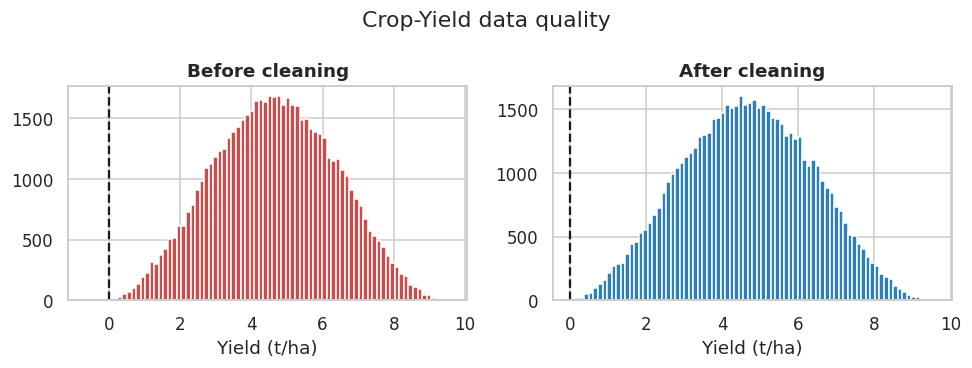

removed 13 negative rows


In [19]:
cy_clean = cy[cy.Yield_tons_per_hectare>=0].copy()
cy_clean["rain_per_day"] = cy_clean.Rainfall_mm / cy_clean.Days_to_Harvest

fig, ax = plt.subplots(1,2, figsize=(9,3.4))
ax[0].hist(cy.Yield_tons_per_hectare, bins=80, color="#cc4c4c"); ax[0].axvline(0,ls="--",c="k")
ax[0].set_title("Before cleaning"); ax[0].set_xlabel("Yield (t/ha)")
ax[1].hist(cy_clean.Yield_tons_per_hectare, bins=80, color="#2c7fb8"); ax[1].axvline(0,ls="--",c="k")
ax[1].set_title("After cleaning"); ax[1].set_xlabel("Yield (t/ha)")
plt.suptitle("Crop-Yield data quality"); plt.tight_layout(); plt.show()
print("removed", len(cy)-len(cy_clean), "negative rows")

### 3.2 Univariate analysis
Distributions of the seven soil/climate variables, with a D'Agostino–Pearson omnibus **normality test**.
Because the data pool 22 very different crops, most variables are **multi-modal** and reject normality —
which motivates the use of robust/non-parametric methods later.

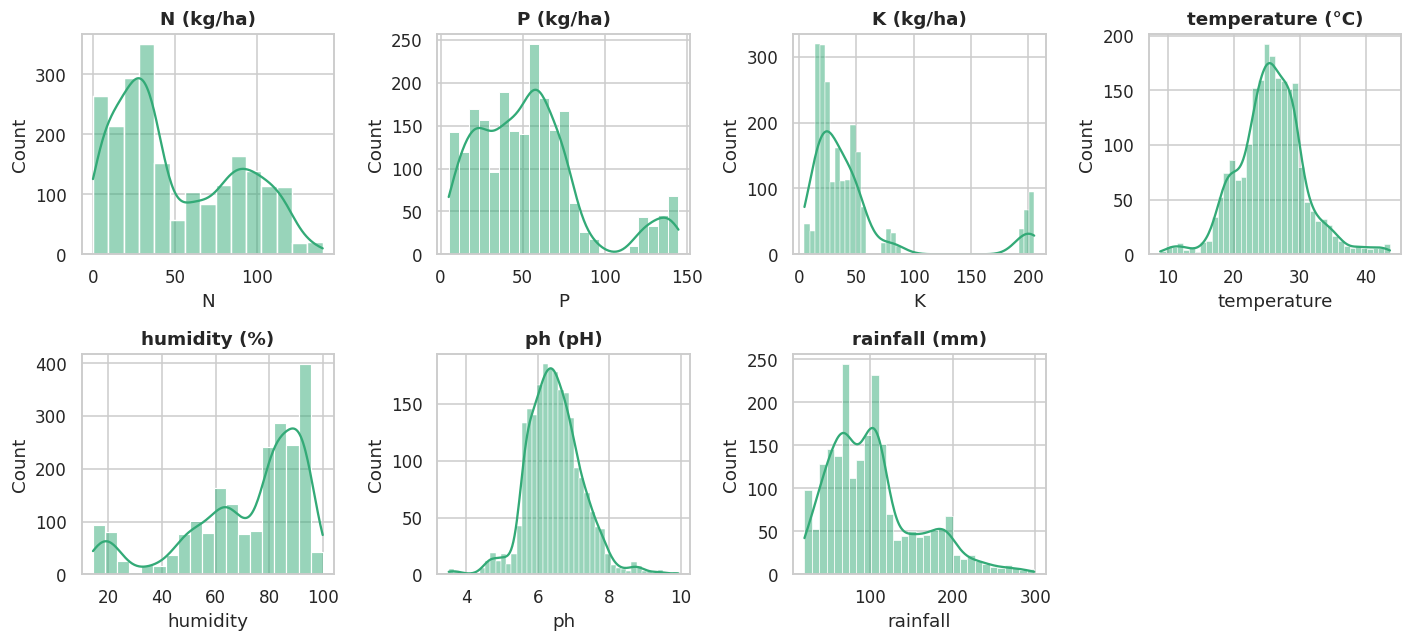

,K2,p,normal_(p>0.05)
N,760.0019,0.0,False
P,302.0868,0.0,False
K,1017.3540,0.0,False
temperature,70.5757,0.0,False
humidity,305.4716,0.0,False
ph,112.7723,0.0,False
rainfall,269.9270,0.0,False


In [20]:
fig, axes = plt.subplots(2,4, figsize=(13,6))
for ax,f in zip(axes.ravel(), FEATS):
    sns.histplot(cr[f], kde=True, ax=ax, color="#3a7"); ax.set_title(f"{f} ({UNITS[f]})")
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()

norm = pd.DataFrame({f: stats.normaltest(cr[f]) for f in FEATS}, index=["K2","p"]).T
norm["normal_(p>0.05)"] = norm.p>0.05
norm.round(4)

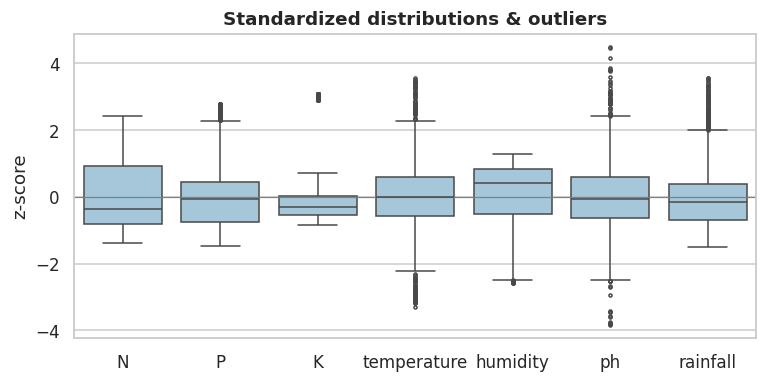

In [21]:
# Standardized boxplots reveal spread and outliers on a common scale
z = (cr[FEATS]-cr[FEATS].mean())/cr[FEATS].std()
plt.figure(figsize=(8,3.6)); sns.boxplot(data=z, color="#9ecae1", fliersize=2)
plt.axhline(0,c="grey",lw=.8); plt.ylabel("z-score"); plt.title("Standardized distributions & outliers"); plt.show()

### 3.3 Bivariate analysis, correlation & outliers
Pearson correlations among the predictors. Phosphorus and potassium are strongly related
(both fertiliser macronutrients); most other pairs are weak, so the variables carry largely
independent information.

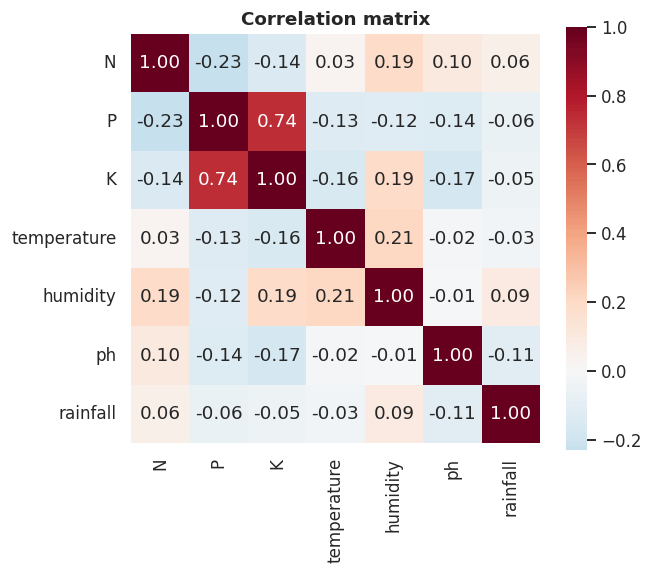

,a,b,r,p
6,P,K,0.736,0.000000e+00
0,N,P,-0.231,3.823471e-28
15,temperature,humidity,0.205,2.274853e-22
3,N,humidity,0.191,1.848573e-19
12,K,humidity,0.191,1.714900e-19


In [22]:
corr = cr[FEATS].corr()
plt.figure(figsize=(6,5)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix"); plt.show()

# significance of each pair
rows=[]
for i in range(len(FEATS)):
    for j in range(i+1,len(FEATS)):
        r,p = stats.pearsonr(cr[FEATS[i]], cr[FEATS[j]]); rows.append((FEATS[i],FEATS[j],round(r,3),p))
pd.DataFrame(rows, columns=["a","b","r","p"]).reindex(
    pd.DataFrame(rows)[2].abs().sort_values(ascending=False).index).head(5)

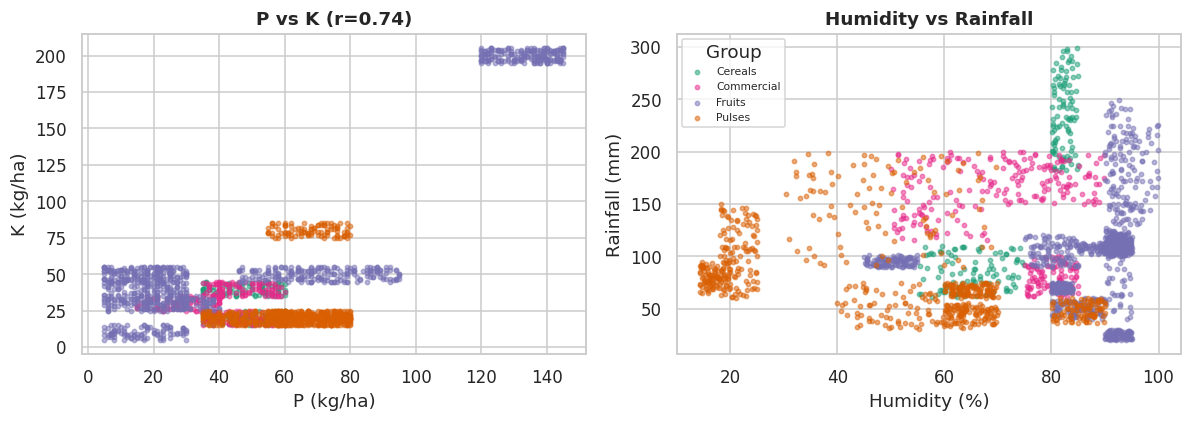

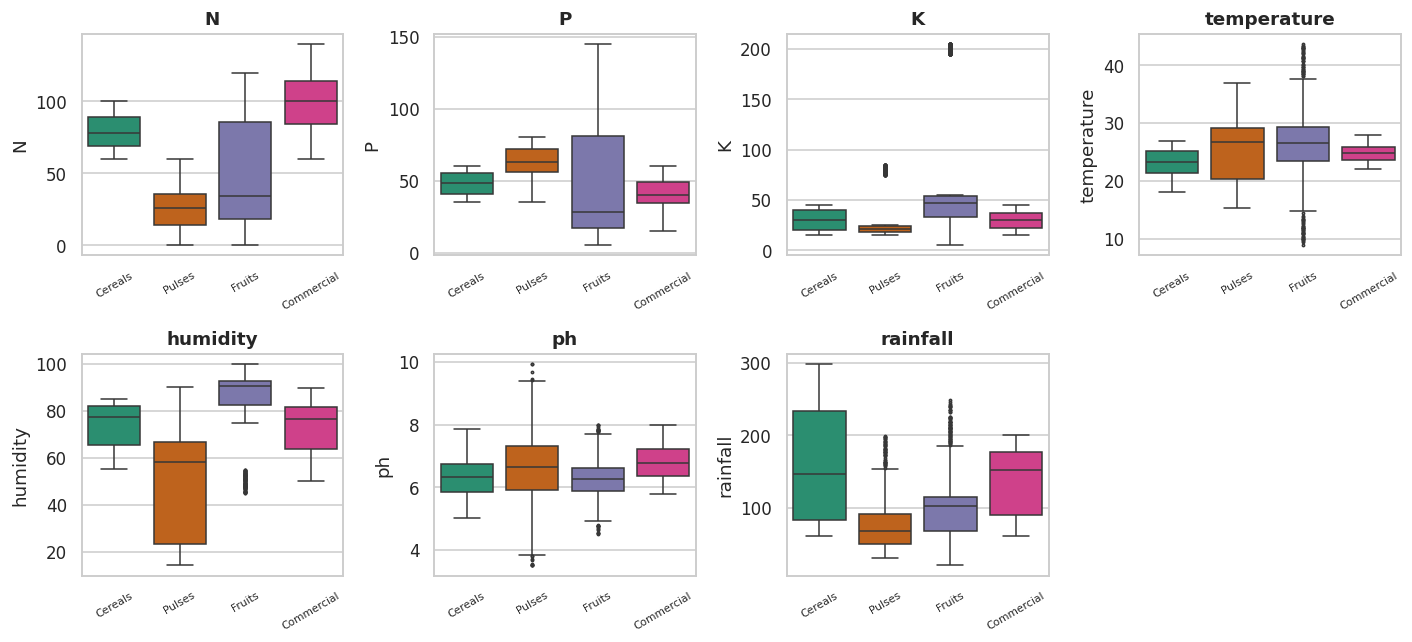

In [23]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
for g,d in cr.groupby("group"):
    ax[0].scatter(d.P,d.K,s=8,alpha=.5,c=PAL[g],label=g)
    ax[1].scatter(d.humidity,d.rainfall,s=8,alpha=.5,c=PAL[g],label=g)
ax[0].set(xlabel="P (kg/ha)",ylabel="K (kg/ha)",title=f"P vs K (r={corr.loc['P','K']:.2f})")
ax[1].set(xlabel="Humidity (%)",ylabel="Rainfall (mm)",title="Humidity vs Rainfall")
ax[1].legend(title="Group",fontsize=7); plt.tight_layout(); plt.show()

# per-group boxplots
fig,axes=plt.subplots(2,4,figsize=(13,6))
for ax,f in zip(axes.ravel(),FEATS):
    sns.boxplot(data=cr,x="group",y=f,order=GROUP_ORDER,hue="group",palette=PAL,legend=False,ax=ax,fliersize=1.5)
    ax.set_title(f); ax.set_xlabel(""); ax.tick_params(axis="x",rotation=30,labelsize=7)
axes.ravel()[-1].axis("off"); plt.tight_layout(); plt.show()

### 3.4 Statistical inference — bootstrap confidence intervals
Estimating group-mean rainfall with non-parametric **bootstrap** 95% CIs (4,000 resamples).
The intervals are narrow and non-overlapping between several groups, anticipating the hypothesis tests.

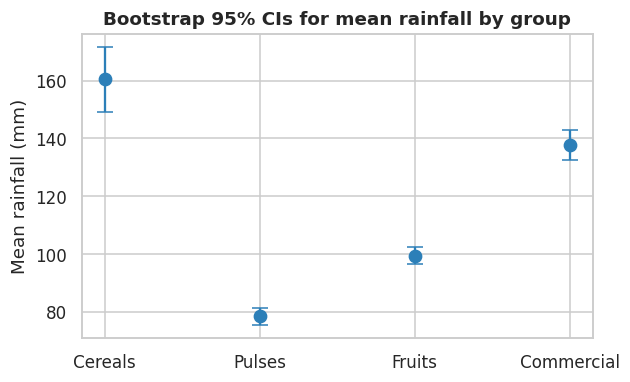

,mean,lo95,hi95
Cereals,160.5,149.1,171.5
Pulses,78.4,75.6,81.2
Fruits,99.3,96.5,102.2
Commercial,137.8,132.6,142.8


In [24]:
def boot_ci(x, n=4000, seed=7):
    rng=np.random.default_rng(seed); x=np.asarray(x)
    bs=[np.mean(rng.choice(x,len(x),replace=True)) for _ in range(n)]
    return np.mean(x), np.percentile(bs,2.5), np.percentile(bs,97.5)

res={g:boot_ci(cr.loc[cr.group==g,"rainfall"]) for g in GROUP_ORDER}
m=[res[g][0] for g in GROUP_ORDER]
lo=[m[i]-res[g][1] for i,g in enumerate(GROUP_ORDER)]; hi=[res[g][2]-m[i] for i,g in enumerate(GROUP_ORDER)]
plt.figure(figsize=(6,3.6)); plt.errorbar(range(4),m,yerr=[lo,hi],fmt="o",capsize=5,ms=8,c="#2c7fb8")
plt.xticks(range(4),GROUP_ORDER); plt.ylabel("Mean rainfall (mm)")
plt.title("Bootstrap 95% CIs for mean rainfall by group"); plt.show()
pd.DataFrame(res, index=["mean","lo95","hi95"]).T.round(1)

### 3.5 Hypothesis testing
**Q (core):** *Do the four crop groups have different soil/climate requirements?* For each variable we run
a one-way **ANOVA** and the non-parametric **Kruskal–Wallis** (appropriate given non-normality). We also
contrast Cereals vs Pulses on nitrogen (Welch t-test + Mann–Whitney).

**Q (supporting, synthetic yield):** which factors actually drive the synthetic yield? ANOVA by soil/region/
weather, a t-test on irrigation, and a χ² test of crop×region independence.

In [25]:
tests=[]
for f in FEATS:
    g=[cr.loc[cr.group==k,f] for k in GROUP_ORDER]
    F,pf=stats.f_oneway(*g); H,ph=stats.kruskal(*g)
    # eta-squared
    grand=cr[f].mean(); ssb=sum(len(x)*(x.mean()-grand)**2 for x in g); sst=((cr[f]-grand)**2).sum()
    tests.append((f,round(F,1),pf,round(H,1),ph,round(ssb/sst,3)))
anova=pd.DataFrame(tests,columns=["var","ANOVA_F","ANOVA_p","Kruskal_H","Kruskal_p","eta2"]).set_index("var")
anova

,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,eta2
var,,,,,
N,557.3,2.868652e-269,804.3,5.114015e-174,0.432
P,34.7,6.276533e-22,329.6,3.851136e-71,0.045
K,151.5,3.089924e-89,599.7,1.162214e-129,0.171
temperature,31.6,5.491199e-20,139.8,4.210604e-30,0.041
humidity,598.9,2.156937e-284,1047.9,7.353711e-227,0.450
ph,59.2,8.457263e-37,205.0,3.437941e-44,0.075
rainfall,206.3,6.801622e-118,412.0,5.513463e-89,0.220


In [26]:
a=cr.loc[cr.group=="Cereals","N"]; b=cr.loc[cr.group=="Pulses","N"]
print("Cereals vs Pulses — Nitrogen")
print("  means: %.1f vs %.1f kg/ha" % (a.mean(), b.mean()))
print("  Welch t: t=%.1f, p=%.2e" % stats.ttest_ind(a,b,equal_var=False))
print("  Mann-Whitney: U=%.0f, p=%.2e" % stats.mannwhitneyu(a,b))

Cereals vs Pulses — Nitrogen
  means: 78.8 vs 26.1 kg/ha
  Welch t: t=52.1, p=2.86e-177
  Mann-Whitney: U=139982, p=2.35e-103


In [27]:
print("SYNTHETIC CROP-YIELD — which factors matter?")
for fac in ["Soil_Type","Region","Weather_Condition"]:
    g=[d.Yield_tons_per_hectare for _,d in cy_clean.groupby(fac)]
    F,p=stats.f_oneway(*g); print(f"  ANOVA yield ~ {fac:18s}: F={F:5.2f}  p={p:.3f}")
F,p=stats.ttest_ind(cy_clean.loc[cy_clean.Irrigation_Used,"Yield_tons_per_hectare"],
                    cy_clean.loc[~cy_clean.Irrigation_Used,"Yield_tons_per_hectare"],equal_var=False)
print(f"  t-test  yield ~ Irrigation     : t={F:6.1f}  p={p:.1e}")
chi2,p,dof,_=stats.chi2_contingency(pd.crosstab(cy_clean.Crop,cy_clean.Region))
print(f"  chi2    Crop x Region          : chi2={chi2:.2f} df={dof} p={p:.3f}")

SYNTHETIC CROP-YIELD — which factors matter?
  ANOVA yield ~ Soil_Type         : F= 0.66  p=0.655
  ANOVA yield ~ Region            : F= 0.36  p=0.783
  ANOVA yield ~ Weather_Condition : F= 0.93  p=0.393
  t-test  yield ~ Irrigation     : t=  92.9  p=0.0e+00
  chi2    Crop x Region          : chi2=7.93 df=15 p=0.927


### 3.6 Multivariate analysis — PCA, LDA, clustering

**PCA** on the standardized predictors describes how crops occupy environmental space.

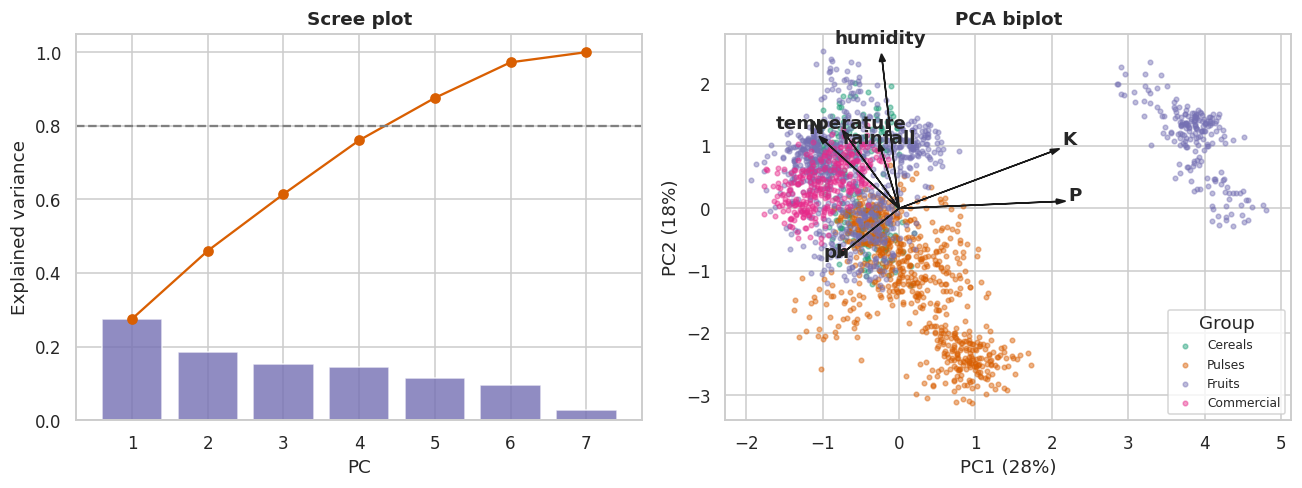

cumulative variance (3 PCs): 61.5%


In [28]:
Xz = StandardScaler().fit_transform(cr[FEATS])
pca = PCA().fit(Xz); scores = pca.transform(Xz); evr = pca.explained_variance_ratio_
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
ax[0].bar(range(1,8),evr,color="#7570b3",alpha=.8); ax[0].plot(range(1,8),evr.cumsum(),"-o",c="#d95f02")
ax[0].axhline(.8,ls="--",c="grey"); ax[0].set(xlabel="PC",ylabel="Explained variance",title="Scree plot")
for g in GROUP_ORDER:
    m=cr.group.values==g; ax[1].scatter(scores[m,0],scores[m,1],s=9,alpha=.45,c=PAL[g],label=g)
load=pca.components_.T*3.2
for i,f in enumerate(FEATS):
    ax[1].arrow(0,0,load[i,0],load[i,1],color="k",head_width=.08); ax[1].text(load[i,0]*1.12,load[i,1]*1.12,f,fontweight="bold",ha="center")
ax[1].set(xlabel=f"PC1 ({evr[0]*100:.0f}%)",ylabel=f"PC2 ({evr[1]*100:.0f}%)",title="PCA biplot")
ax[1].legend(title="Group",fontsize=8); plt.tight_layout(); plt.show()
print("cumulative variance (3 PCs): %.1f%%" % (evr[:3].sum()*100))

**LDA** finds the axes that best separate the agronomic groups, and gives a transparent classifier.

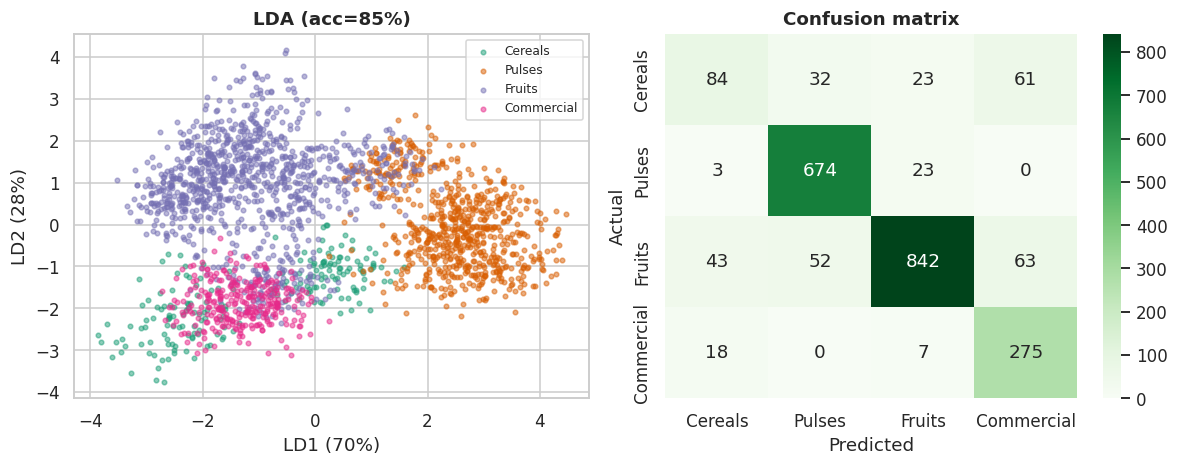

In [29]:
lda=LinearDiscriminantAnalysis()
ld=lda.fit_transform(Xz, cr.group); pred=lda.predict(Xz)
acc=(pred==cr.group).mean()
fig,ax=plt.subplots(1,2,figsize=(11,4.4))
for g in GROUP_ORDER:
    m=cr.group.values==g; ax[0].scatter(ld[m,0],ld[m,1],s=9,alpha=.5,c=PAL[g],label=g)
ax[0].set(xlabel=f"LD1 ({lda.explained_variance_ratio_[0]*100:.0f}%)",
          ylabel=f"LD2 ({lda.explained_variance_ratio_[1]*100:.0f}%)",title=f"LDA (acc={acc*100:.0f}%)")
ax[0].legend(fontsize=8)
cm=confusion_matrix(cr.group,pred,labels=GROUP_ORDER)
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",xticklabels=GROUP_ORDER,yticklabels=GROUP_ORDER,ax=ax[1])
ax[1].set(xlabel="Predicted",ylabel="Actual",title="Confusion matrix"); plt.tight_layout(); plt.show()

**Clustering.** Hierarchical (Ward) dendrogram of the 22 crop means, plus K-means agreement with the agronomic groups (Adjusted Rand Index).

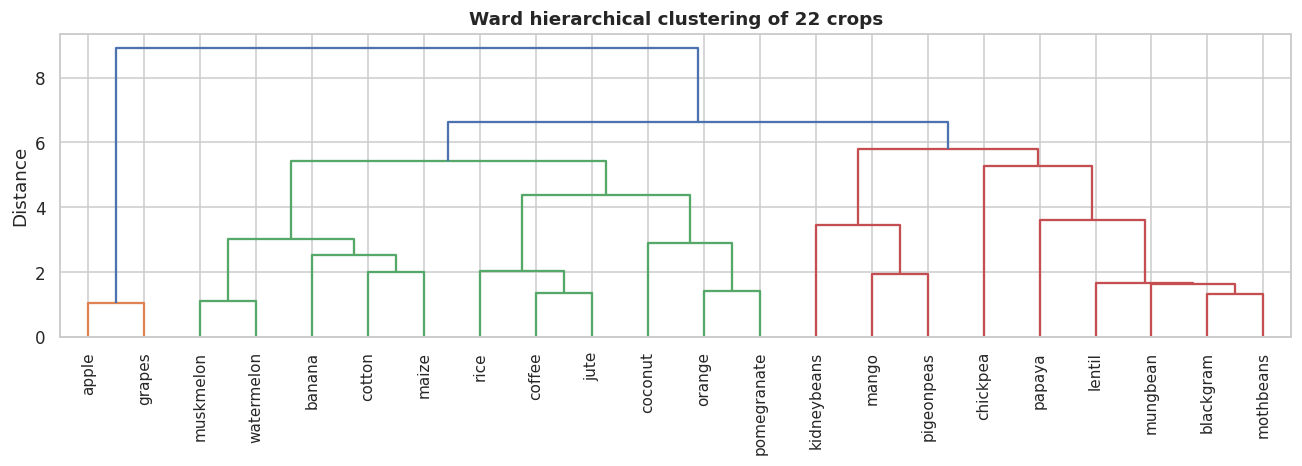

K-means vs agronomic groups — Adjusted Rand Index: 0.336


In [30]:
cz=cr.groupby("label")[FEATS].mean(); czz=StandardScaler().fit_transform(cz)
Z=linkage(czz, method="ward")
plt.figure(figsize=(12,4.4)); dendrogram(Z, labels=cz.index.tolist(), leaf_rotation=90)
plt.title("Ward hierarchical clustering of 22 crops"); plt.ylabel("Distance"); plt.tight_layout(); plt.show()

km=KMeans(4, random_state=RNG, n_init=10).fit_predict(Xz)
print("K-means vs agronomic groups — Adjusted Rand Index: %.3f" % adjusted_rand_score(cr.group, km))

### 3.7 Geographical & temporal patterns (OECD real data)
This addresses the project's *"geographical patterns and temporal trends"* requirement with **real**
FAO/OECD yields. **Temporal:** world yields rose steadily 1990–2025 for all four crops (linear-trend
regression). **Geographical:** maize yields differ significantly across continents.

MAIZE   : +0.77 t/ha per decade (r=0.98, p=8.7e-24)
RICE    : +0.34 t/ha per decade (r=0.99, p=2.6e-28)
WHEAT   : +0.34 t/ha per decade (r=0.97, p=2.0e-20)
SOYBEAN : +0.26 t/ha per decade (r=0.95, p=1.3e-16)


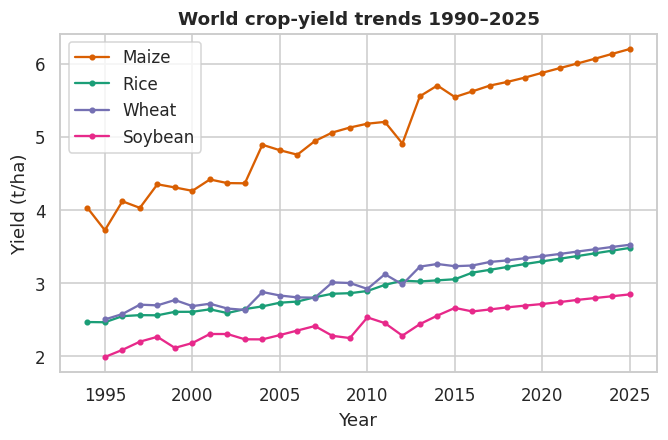


ANOVA maize yield by continent: F=3.05, p=0.028


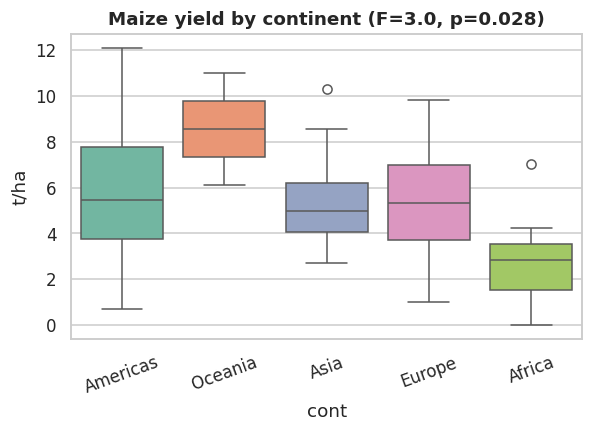

In [31]:
AGG={"BRICS","EU28","OECD","WLD","SSA"}
CONT={**{c:"Americas" for c in ["ARG","BRA","CAN","CHL","COL","HTI","MEX","PER","PRY","URY","USA"]},
 **{c:"Asia" for c in ["BGD","CHN","IDN","IND","IRN","ISR","JPN","KAZ","KOR","MYS","PAK","PHL","SAU","THA","VNM","TUR"]},
 **{c:"Africa" for c in ["DZA","EGY","ETH","GHA","MOZ","NGA","SDN","TZA","ZAF","ZMB"]},
 **{c:"Europe" for c in ["CHE","NOR","RUS","UKR"]}, **{c:"Oceania" for c in ["AUS","NZL"]}}
oc=oecd[~oecd.country.isin(AGG)].copy(); oc["cont"]=oc.country.map(CONT)
wld=oecd[oecd.country=="WLD"]

# temporal
plt.figure(figsize=(7,4)); cols={"MAIZE":"#d95f02","RICE":"#1b9e77","WHEAT":"#7570b3","SOYBEAN":"#e7298a"}
for crp in cols:
    d=wld[wld.crop==crp].sort_values("year")
    plt.plot(d.year,d.yield_t_ha,"-o",ms=3,c=cols[crp],label=crp.title())
    sl,inter,r,p,se=stats.linregress(d.year,d.yield_t_ha)
    print(f"{crp:8s}: +{sl*10:.2f} t/ha per decade (r={r:.2f}, p={p:.1e})")
plt.legend(); plt.xlabel("Year"); plt.ylabel("Yield (t/ha)"); plt.title("World crop-yield trends 1990–2025"); plt.show()

# geographical
recent=oc[(oc.year>=2015)&(oc.crop=="MAIZE")].groupby(["country","cont"]).yield_t_ha.mean().reset_index()
g=[d.yield_t_ha for _,d in recent.groupby("cont") if len(d)>=2]
F,p=stats.f_oneway(*g); print(f"\nANOVA maize yield by continent: F={F:.2f}, p={p:.3f}")
plt.figure(figsize=(6,3.6)); sns.boxplot(data=recent,x="cont",y="yield_t_ha",palette="Set2")
plt.title(f"Maize yield by continent (F={F:.1f}, p={p:.3f})"); plt.ylabel("t/ha"); plt.xticks(rotation=20); plt.show()

**Interactive visualisation (Plotly):** a choropleth of maize yield and an animated/interactive yield-trend explorer (renders in Colab; see the standalone HTML dashboard for the full version).

In [32]:
import plotly.express as px
recent_all = oc[oc.year>=2015].groupby(["country","crop"]).yield_t_ha.mean().reset_index()
fig = px.choropleth(recent_all[recent_all.crop=="MAIZE"], locations="country",
                    color="yield_t_ha", color_continuous_scale="YlGn",
                    title="Mean maize yield 2015–2025 (t/ha)")
fig.show()

trend = oc.groupby(["year","crop"]).yield_t_ha.mean().reset_index()
fig2 = px.line(trend, x="year", y="yield_t_ha", color="crop", markers=True,
               title="Mean national crop yields over time")
fig2.show()

## 4. Discussion / Conclusions
See the written report (Chapter 4). In brief: (1) crops occupy distinct, statistically separable
envelopes in soil–climate space, dominated by an N–P–K fertility axis and a humidity/temperature axis;
(2) LDA separates agronomic groups at ~85% accuracy, with the "Cereals" group the least coherent
(rice and maize have very different water needs); (3) clustering only partly recovers botanical groups —
environmental niche cuts across taxonomy; (4) in the **synthetic** yield data only management variables
(irrigation, fertiliser) carry signal, a cautionary tale on external validity; (5) **real** OECD data show
strong, significant yield growth (1990–2025) and significant geographical contrasts (Oceania/Americas high,
Africa low).

---
## AI-usage declaration
In line with the course policy, we declare all use of AI assistants.

**Tools used:** ChatGPT / Claude (general-purpose LLM assistants).

**Where used and how:**
- *Code scaffolding:* drafting boilerplate for matplotlib/seaborn figure layouts and the bootstrap helper.
- *Statistics check:* confirming the correct SciPy function and assumptions for each test (e.g. Welch t-test vs Mann–Whitney; Kruskal–Wallis as the non-parametric ANOVA).
- *Writing:* light copy-editing of the report prose.

**Representative prompts** :
1. "Write a Python function that returns a 95% bootstrap confidence interval for the mean of a NumPy array using 4000 resamples."
2. "Given non-normal data with four groups, which SciPy test is the non-parametric equivalent of one-way ANOVA, and how do I call it?"
3. "Draft matplotlib code for a PCA biplot that colours points by a categorical group and overlays the loading vectors as arrows."

**Verification:** every AI-suggested snippet was executed, checked against the data, and edited by us.
All statistical results in this notebook were produced by the code shown here, not by an AI.